In [1]:
from pathlib import Path

out = Path('../out/2020-08-25').resolve()

In [3]:
import json
import re
import numpy as np 

scores = {}
genomes = {}
rs = []
rows = []
for p in out.iterdir():
    if p.suffix == '':
        g = re.search('gen_0*(\d+)', str(p)).groups()[0]
        scores_d = json.load((p/'scores.json').open())
        genomes[g] = {re.search('sim_0*(\d+)', str(i)).groups()[0]: json.load((p/i/'genome.json').open())['signaling']['halfexpress'] for i in p.iterdir() if i.suffix == ''}
        for k in scores_d:
            d = np.array(json.load((p/f'sim_{int(k):03}'/'data.json').open()))
            rs.extend([[g, k, t, f] for t, f in d])
        rows.extend([[g, k, s, genomes[g][k]] for k, s in scores_d.items()])

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
datas = pd.DataFrame(rs, columns=['gen', 'sim', 't', 'fitness'])

In [7]:
ave_f = datas.groupby(['gen', 'sim']).fitness.pipe(lambda x: x.mean() - x.std()/x.mean()).reset_index()

In [8]:
gd = [[[g, s, beta] for s, beta in v.items()] for g, v in genomes.items()]

In [9]:
rs = []
for i in gd:
    rs.extend(i)

In [10]:
gs = pd.DataFrame(rs, columns=['gen', 'sim', 'beta'])

In [11]:
gdf = ave_f.merge(gs, on=['gen', 'sim'])

In [12]:
gdf

,gen,sim,fitness,beta
0,1,0,0.084550,11621.882456
1,1,1,-0.040482,11998.275805
2,1,10,0.833253,-1471.484801
3,1,100,-0.011785,-16420.813019
4,1,101,-0.321470,19990.167407
...,...,...,...,...
1275,5,95,0.845550,3474.673990
1276,5,96,0.850007,-1277.233926
1277,5,97,0.823814,5172.255500
1278,5,98,0.871952,-212.816199


In [19]:
gdf.gen = gdf.gen.astype(int)

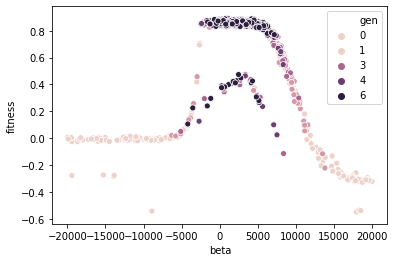

In [20]:
sns.scatterplot(data=gdf, x='beta', y='fitness', hue='gen')

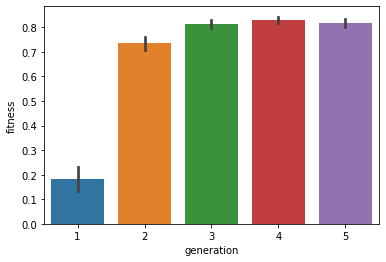

In [22]:
sns.barplot(x='gen', y='fitness', data=gdf)
plt.xlabel('generation')
plt.savefig('f_over_g', dpi=600)

In [14]:
gdf.head()

,gen,sim,fitness,beta
0,1,0,0.084550,11621.882456
1,1,1,-0.040482,11998.275805
2,1,10,0.833253,-1471.484801
3,1,100,-0.011785,-16420.813019
4,1,101,-0.321470,19990.167407


In [29]:
Fmu = gdf.fitness.mean()
gdf.loc[gdf.fitness.ge(Fmu), 'good'] = True
gdf.loc[gdf.fitness.lt(Fmu), 'good'] = False

In [30]:
golden = (1 + 5 ** 0.5) / 2

In [37]:
for gen, gendf in gdf.groupby('gen'):
    Nmu = gendf.loc[gendf.good.eq(True)].beta.mean()
    Nsd = np.ptp(gendf.loc[gendf.good.eq(True)].beta)/4
    newbetas = np.random.normal(Nmu, Nsd, 500)
    fig = sns.scatterplot(data=gendf, hue='good', x='beta', y='fitness')
    plt.annotate('ave fitness', (-20000, gendf.fitness.mean()+.05), color='m')
    ax = fig.axes
    ax.hlines(y=gendf.fitness.mean(), xmin=-20000, xmax=20000, ls='--', color='m')
    ax.vlines(x=Nmu, ymin=gendf.fitness.min(), ymax=gendf.fitness.max(), ls='--', color='g')
    fig = sns.distplot(newbetas, hist=False, ax=ax.twinx(), color='g')
    fig.axes.set_axis_off()
    ax.get_legend().remove()
    plt.title(f'generation {gen}')
    plt.savefig(f'dists/gen{gen}', dpi=600, bbox_inches='tight')
    plt.close()

In [260]:
gdf.sort_values(by='fitness', ascending=False).head(20)

,gen,sim,fitness,beta,good
84,1,85,0.870904,1940.258163,True
72,1,74,0.870371,-104.331805,True
58,1,61,0.869445,2824.234391,True
16,1,23,0.868272,1203.974880,True
25,1,31,0.866114,-2239.059832,True
7,1,15,0.864706,2559.167456,True
66,1,69,0.863454,4943.954840,True
79,1,80,0.863023,2583.413183,True
6,1,14,0.859573,275.630518,True
75,1,77,0.856235,-1713.722877,True


In [47]:
gdf[gdf.beta.lt(-6000)].head()

,gen,sim,fitness,beta
2,1,10,0.004740,-6969.425531
9,1,17,-0.013157,-6353.147098
10,1,18,-0.006209,-6733.394939
20,1,27,0.001238,-6204.674645
26,1,32,-0.014311,-7602.714283


In [49]:
gdf[gdf.beta.gt(15000)].head()

,gen,sim,fitness,beta
75,2,33,-0.278366,15094.869713
124,3,34,-0.291513,15773.605347
242,6,10,-0.294318,15276.550890
384,9,0,-0.315748,16959.136791


In [48]:
gdf[gdf.beta.ge(0) & gdf.beta.lt(5000)].head()

,gen,sim,fitness,beta
0,1,0,0.879442,1660.074403
4,1,12,0.872836,73.417575
5,1,13,0.848398,699.459059
18,1,25,0.870141,4401.076279
27,1,33,0.854063,2137.795601


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

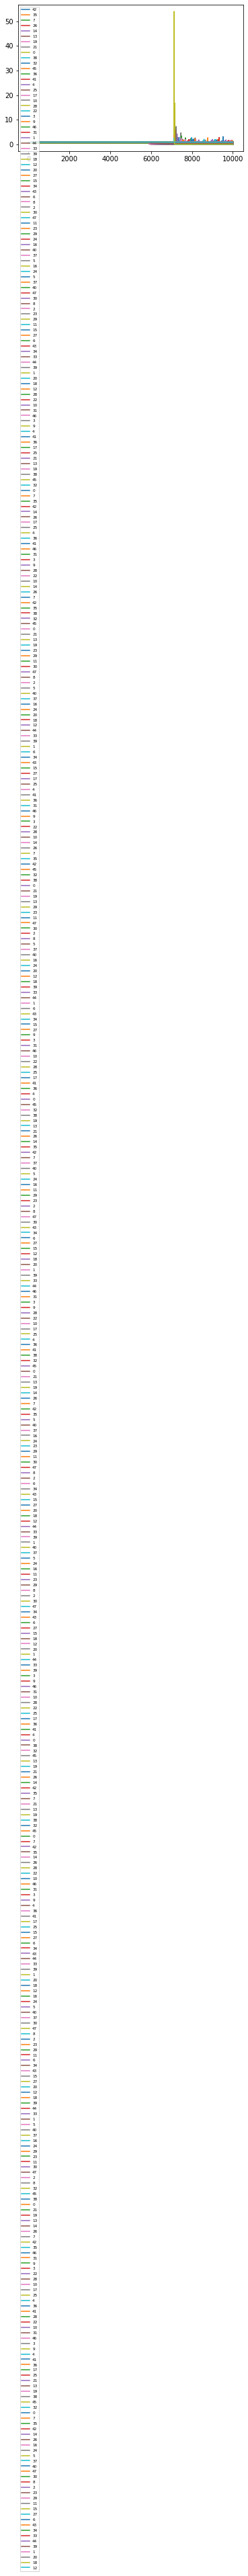

In [7]:
import numpy as np
for g in datas:
    for s in datas[g]:
        d = np.array(datas[g][s])
        plt.plot(d[:, 0], d[:, 1], label=s)
    plt.legend(loc='upper left', fontsize='xx-small')
    plt.savefig(f'datas/gen_{g}', dpi=600)

NameError: name 'df' is not defined

In [177]:
import pandas as pd

df = pd.DataFrame(rows, columns=['gen', 'sim', 'score', 'beta'])

In [181]:
med = df.groupby('gen').score.median().reset_index().rename(columns={'score': 'med'})

In [182]:
df = df.merge(med, on='gen')

In [183]:
middles = df.groupby('gen').apply(lambda x: (x.score - x.med).abs().idxmin())

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

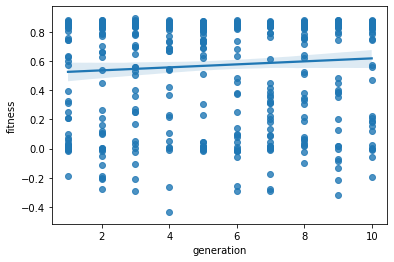

In [187]:
sns.regplot(x='gen', y='score', data=df)
plt.xlabel('generation')
plt.ylabel('fitness')
plt.savefig('f_over_g.png', dpi=600)

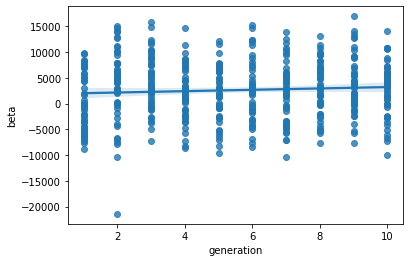

In [192]:
sns.regplot(x='gen', y='beta', data=df)
plt.xlabel('generation')
plt.ylabel('beta')
plt.savefig('b_over_g.png', dpi=600, bbox_inches='tight')